K-Means Clustering Algorithms Implementation

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
%matplotlib inline

In [68]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2,random_state=23)

In [69]:
X.shape

(1000, 2)

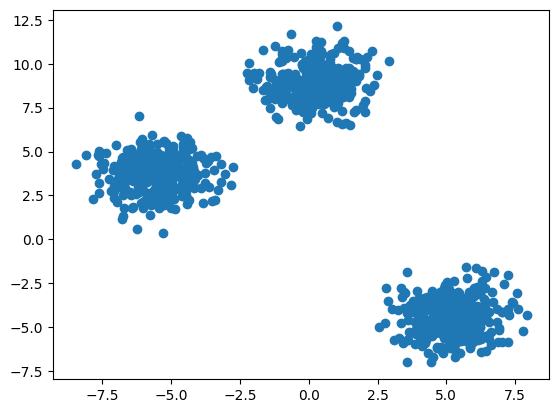

In [70]:
plt.scatter(X[:,0],X[:,1])

In [71]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [72]:
from sklearn.cluster import KMeans

In [73]:
##Manual Process
##Elbow Method to select the k-Value
WCSS = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train)
    WCSS.append(kmeans.inertia_)

In [74]:
WCSS

[34827.576825520235,
 7935.437286145425,
 1319.2730531585605,
 1180.9798742813507,
 1032.6039362199738,
 916.4106104803164,
 892.9903603504355,
 665.8907131792264,
 591.2381618963866,
 545.7658983646786]

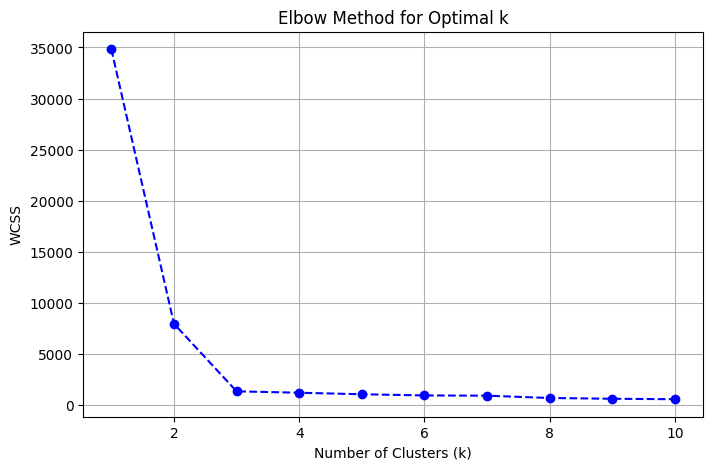

In [75]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), WCSS, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [76]:
kmeans = KMeans(n_clusters=3, init='k-means++')

In [77]:
y_labels=kmeans.fit_predict(X_train)

In [78]:
y_test_labels=kmeans.predict(X_test)

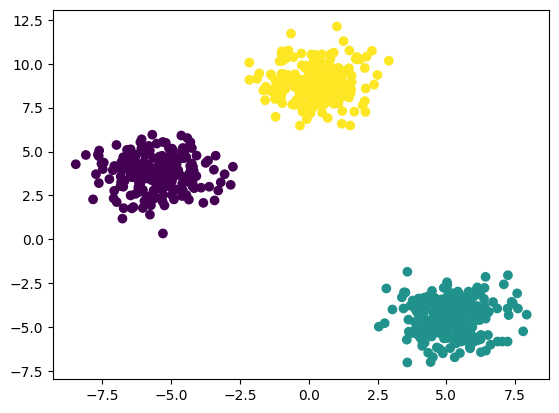

In [79]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_labels)

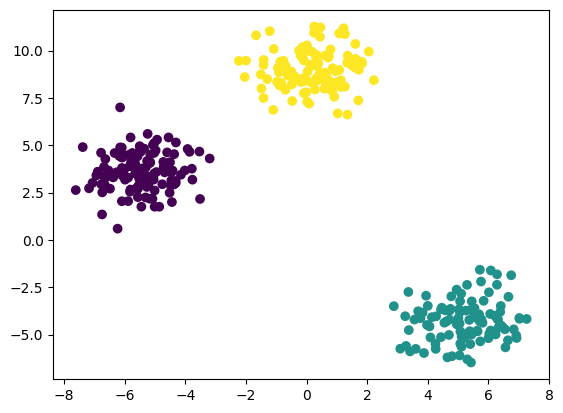

In [80]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_test_labels)

In [81]:
##Kneed locator
!pip install kneed

In [82]:
from kneed import KneeLocator

In [83]:
kl=KneeLocator(range(1,11),WCSS,curve='convex',direction='decreasing')
kl.elbow

np.int64(3)

In [84]:
##Performance metrics
##Silhouette Score
from sklearn.metrics import silhouette_score

In [86]:
silhouette_coefficients=[]
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train)
    score=silhouette_score(X_train,kmeans.labels_)
    silhouette_coefficients.append(score)

In [87]:
silhouette_coefficients

[np.float64(0.7281443868598331),
 np.float64(0.8071181203797672),
 np.float64(0.6519643024137518),
 np.float64(0.48775142591702614),
 np.float64(0.4799490645204189),
 np.float64(0.33513622835934276),
 np.float64(0.3214216050650943),
 np.float64(0.34195839811061135),
 np.float64(0.3251765745325569)]

<function matplotlib.pyplot.show(close=None, block=None)>

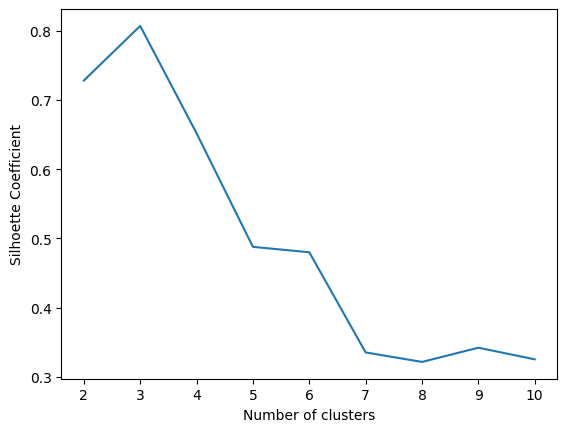

In [90]:
##ploting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel('Number of clusters')
plt.ylabel('Silhoette Coefficient')
plt.show